In [1]:
###Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
###Loading the dataset
df = pd.read_csv('../data/raw/HR_capstone_dataset.csv')

In [3]:
###Displaying the first few rows of the dataset
df.head(10)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
5,0.41,0.50,2,153,3,0,1,0,sales,low
6,0.10,0.77,6,247,4,0,1,0,sales,low
7,0.92,0.85,5,259,5,0,1,0,sales,low
8,0.89,1.00,5,224,5,0,1,0,sales,low
9,0.42,0.53,2,142,3,0,1,0,sales,low


In [4]:
###Data Exploration
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB


In [5]:
###Summary statistics of the dataset
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [6]:
###Data Cleaning and Preprocessing
df = df.rename(columns={'Work_accident': 'work_accident',
                          'average_montly_hours': 'average_monthly_hours',
                          'time_spend_company': 'tenure',
                          'Department': 'department'})

In [7]:
###Checking for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

df = df.drop_duplicates(keep='first')
print(f"Cleaned dataset shape: {df.shape}")

Number of duplicate rows: 3008
Cleaned dataset shape: (11991, 10)


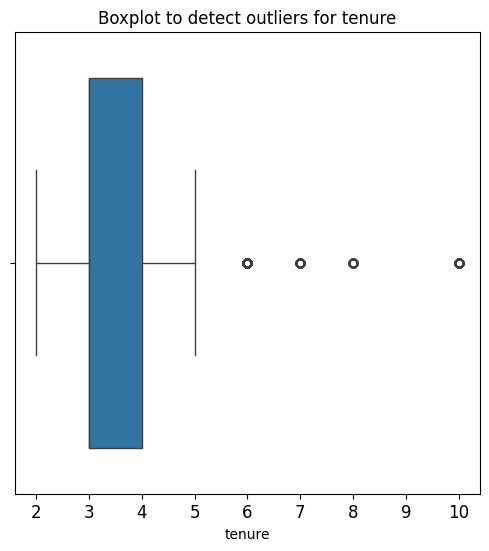

In [8]:
###Boxplot to detect outliers for tenure
plt.figure(figsize=(6,6))
plt.title('Boxplot to detect outliers for tenure', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
sns.boxplot(x=df['tenure'])
plt.show()

In [9]:
### Determine the number of rows containing outliers 
### YOUR CODE HERE ###

### Compute the 25th percentile value in `tenure`
percentile25 = df['tenure'].quantile(0.25)

### Compute the 75th percentile value in `tenure`
percentile75 = df['tenure'].quantile(0.75)

### Compute the interquartile range in `tenure`
iqr = percentile75 - percentile25

### Define the upper limit and lower limit for non-outlier values in `tenure`
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr
print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

### Identify subset of data containing outliers in `tenure`
outliers = df[(df['tenure'] > upper_limit) | (df['tenure'] < lower_limit)]

### Count how many rows in the data contain outliers in `tenure`
print("Number of rows in the data containing outliers in `tenure`:", len(outliers))

Lower limit: 1.5
Upper limit: 5.5
Number of rows in the data containing outliers in `tenure`: 824


left
0    10000
1     1991
Name: count, dtype: int64

Percentage distribution of 'left':
left
0    83.39588
1    16.60412
Name: proportion, dtype: float64


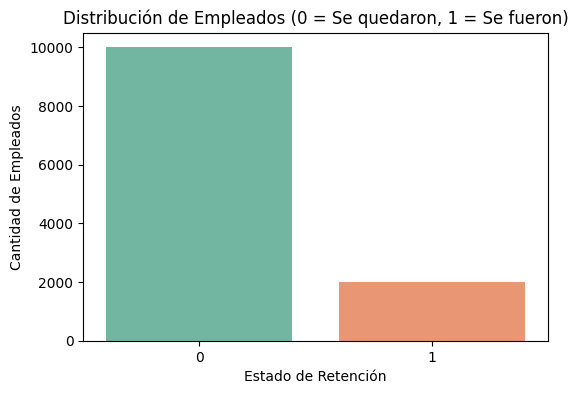

In [10]:
### Analyzing the target variable 'left'
print(df['left'].value_counts())
print("\nPercentage distribution of 'left':")
print(df['left'].value_counts(normalize=True) * 100)


### Charting the distribution of the target variable 'left'
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='left', hue='left', palette='Set2', legend=False)
plt.title('Distribución de Empleados (0 = Se quedaron, 1 = Se fueron)')
plt.xlabel('Estado de Retención')
plt.ylabel('Cantidad de Empleados')
plt.show()

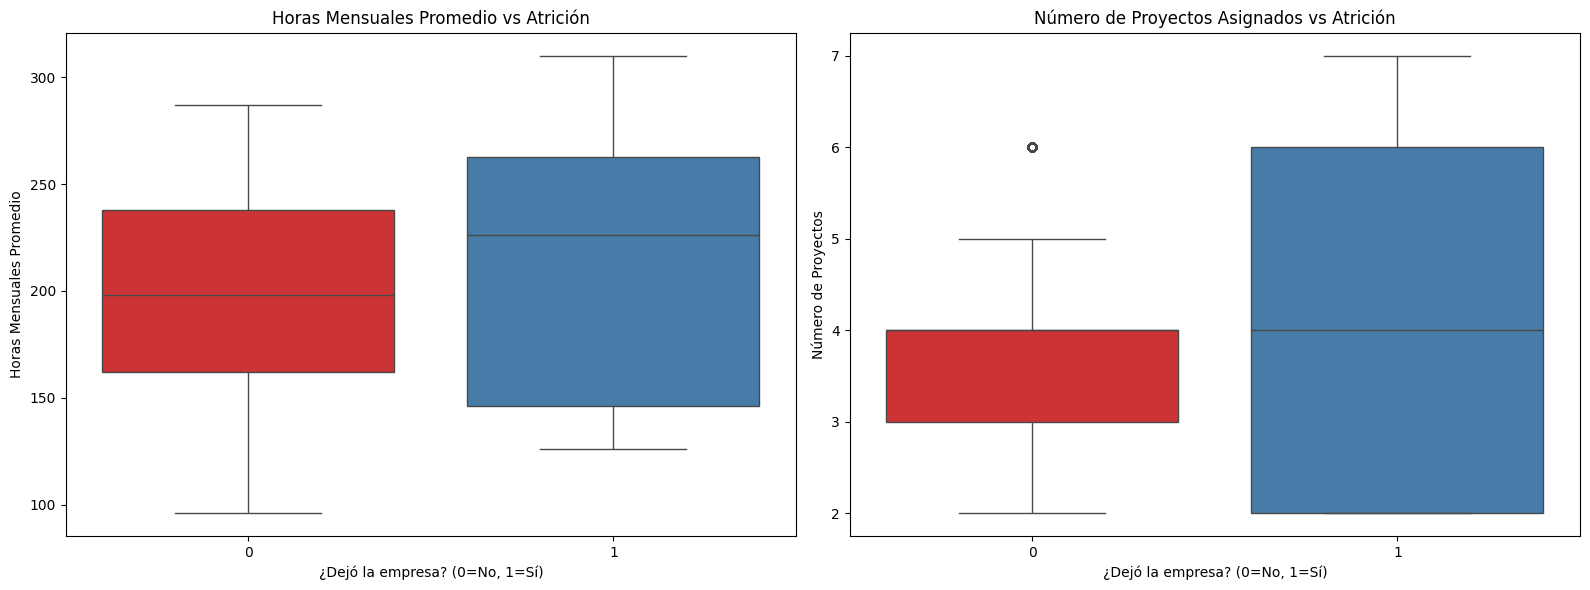

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot of Average Monthly Hours vs Attrition (Fixed column to average_monthly_hours)
sns.boxplot(data=df, x='left', y='average_monthly_hours', hue='left', ax=ax[0], palette='Set1', legend=False)
ax[0].set_title('Horas Mensuales Promedio vs Atrición')
ax[0].set_xlabel('¿Dejó la empresa? (0=No, 1=Sí)')
ax[0].set_ylabel('Horas Mensuales Promedio')

# Boxplot of Number of Projects vs Attrition
sns.boxplot(data=df, x='left', y='number_project', hue='left', ax=ax[1], palette='Set1', legend=False)
ax[1].set_title('Número de Proyectos Asignados vs Atrición')
ax[1].set_xlabel('¿Dejó la empresa? (0=No, 1=Sí)')
ax[1].set_ylabel('Número de Proyectos')

plt.tight_layout()
plt.show()

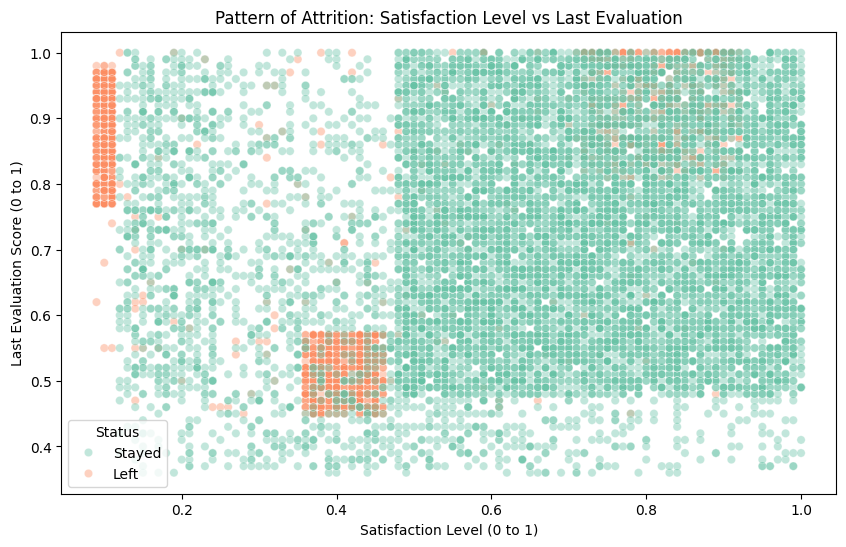

In [12]:
### Scatter plot of satisfaction level vs last evaluation, colored by attrition status (Fixed legend labels)
plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(data=df, x='satisfaction_level', y='last_evaluation', hue='left', alpha=0.4, palette='Set2')
plt.title('Pattern of Attrition: Satisfaction Level vs Last Evaluation')
plt.xlabel('Satisfaction Level (0 to 1)')
plt.ylabel('Last Evaluation Score (0 to 1)')

# Retrieve default handles and labels, and set custom legend mapping (0 = Stayed, 1 = Left)
handles, labels = scatter.get_legend_handles_labels()
plt.legend(handles, ['Stayed', 'Left'], title='Status')

plt.show()

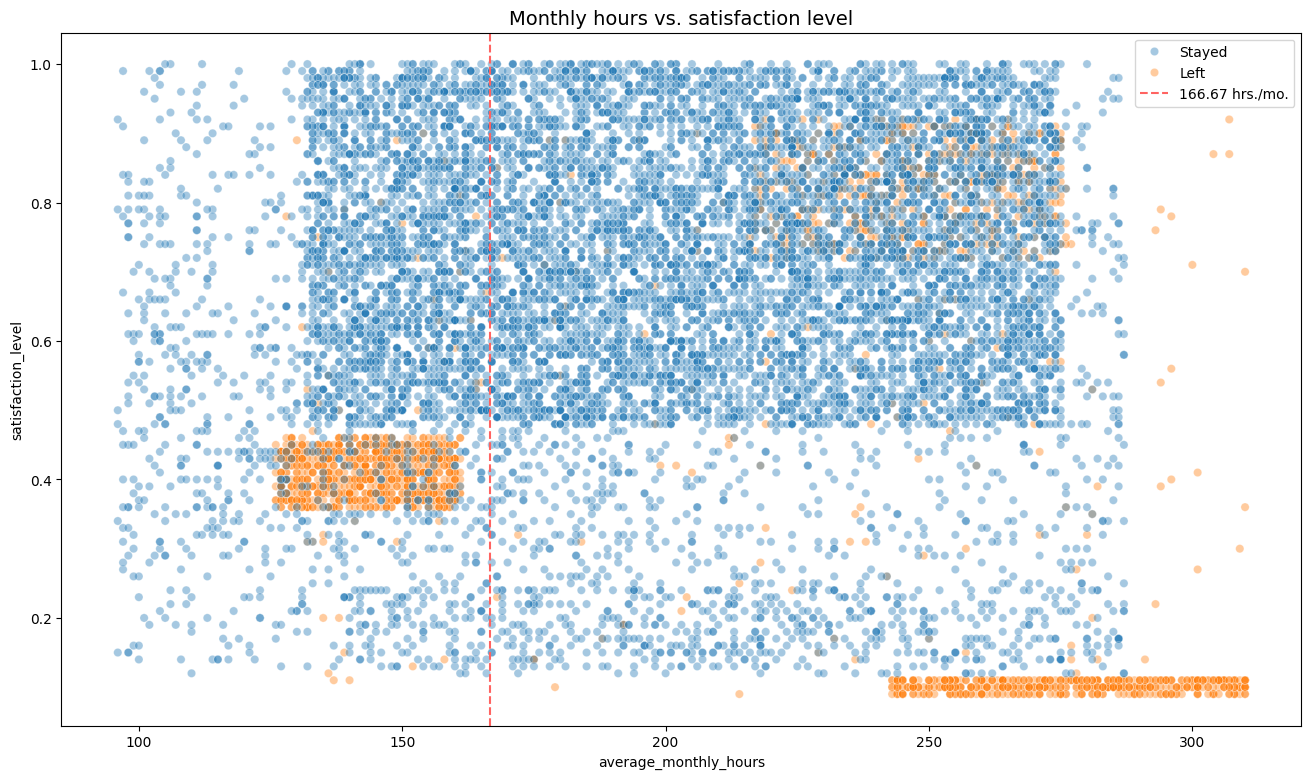

In [13]:
## Scatter plot of average_monthly_hours versus satisfaction_level (Fixed legend and title)
plt.figure(figsize=(16, 9))
scatter = sns.scatterplot(data=df, x='average_monthly_hours', y='satisfaction_level', hue='left', alpha=0.4)
line = plt.axvline(x=166.67, color='#ff6361', ls='--')

# Correctly assign legend labels using handles
handles, labels = scatter.get_legend_handles_labels()
handles.append(line)
plt.legend(handles=handles, labels=['Stayed', 'Left', '166.67 hrs./mo.'])
plt.title('Monthly hours vs. satisfaction level', fontsize='14')
plt.show()

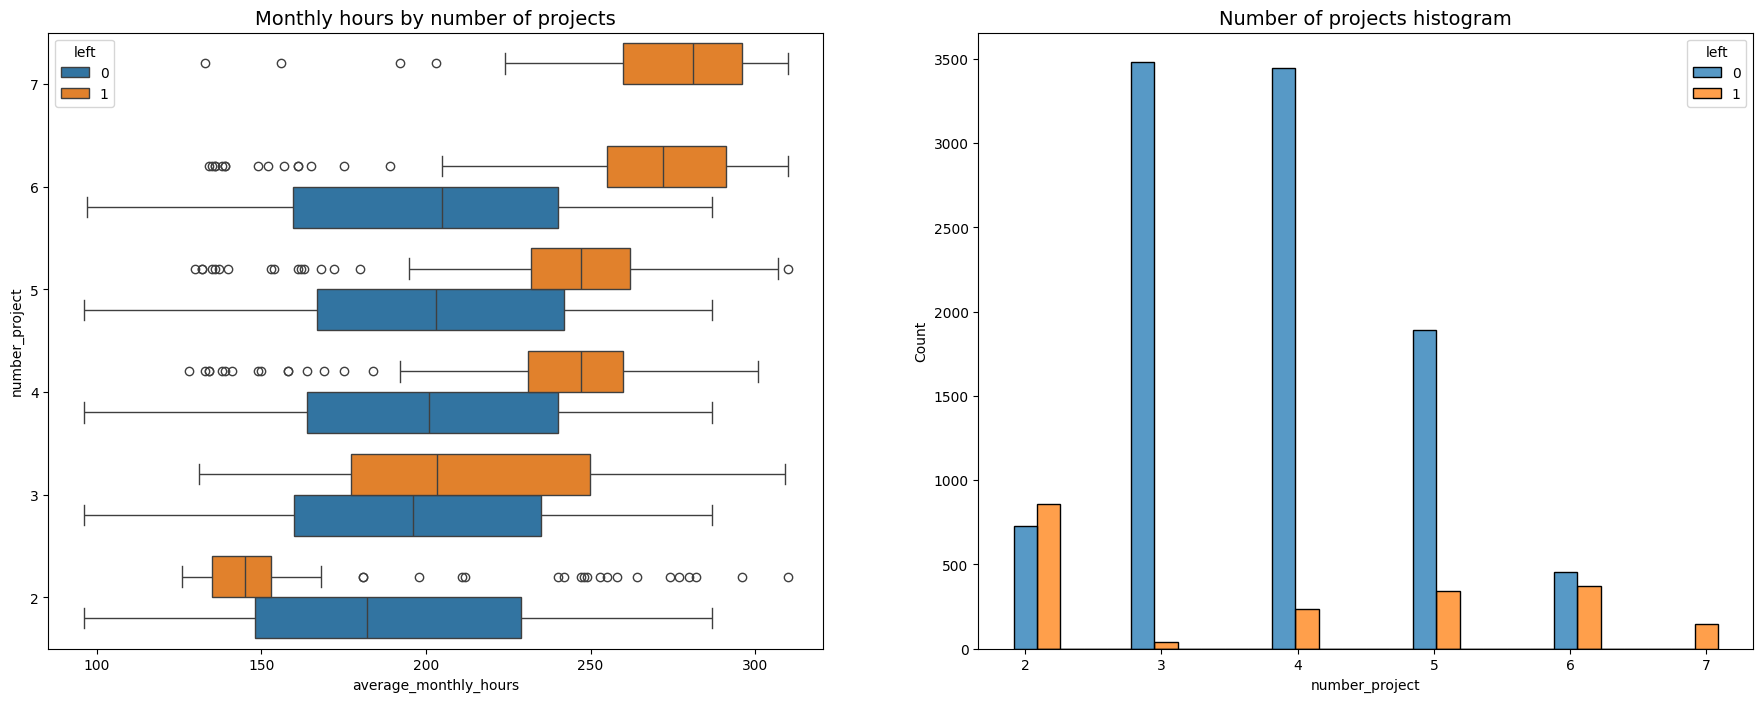

In [14]:

fig, ax = plt.subplots(1, 2, figsize = (22,8))

### Boxplot showing `average_monthly_hours` distributions for `number_project`, comparing employees who stayed versus those who left
sns.boxplot(data=df, x='average_monthly_hours', y='number_project', hue='left', orient="h", ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Monthly hours by number of projects', fontsize='14')

### Histogram showing distribution of `number_project`, comparing employees who stayed versus those who left
tenure_stay = df[df['left']==0]['number_project']
tenure_left = df[df['left']==1]['number_project']
sns.histplot(data=df, x='number_project', hue='left', multiple='dodge', shrink=2, ax=ax[1])
ax[1].set_title('Number of projects histogram', fontsize='14')
plt.show()

In [15]:
###Summarize the mean and median satisfaction level for employees who stayed versus those who left
df.groupby(['left'])['satisfaction_level'].agg([np.mean,np.median])

,mean,median
left,,
0,0.667365,0.69
1,0.440271,0.41


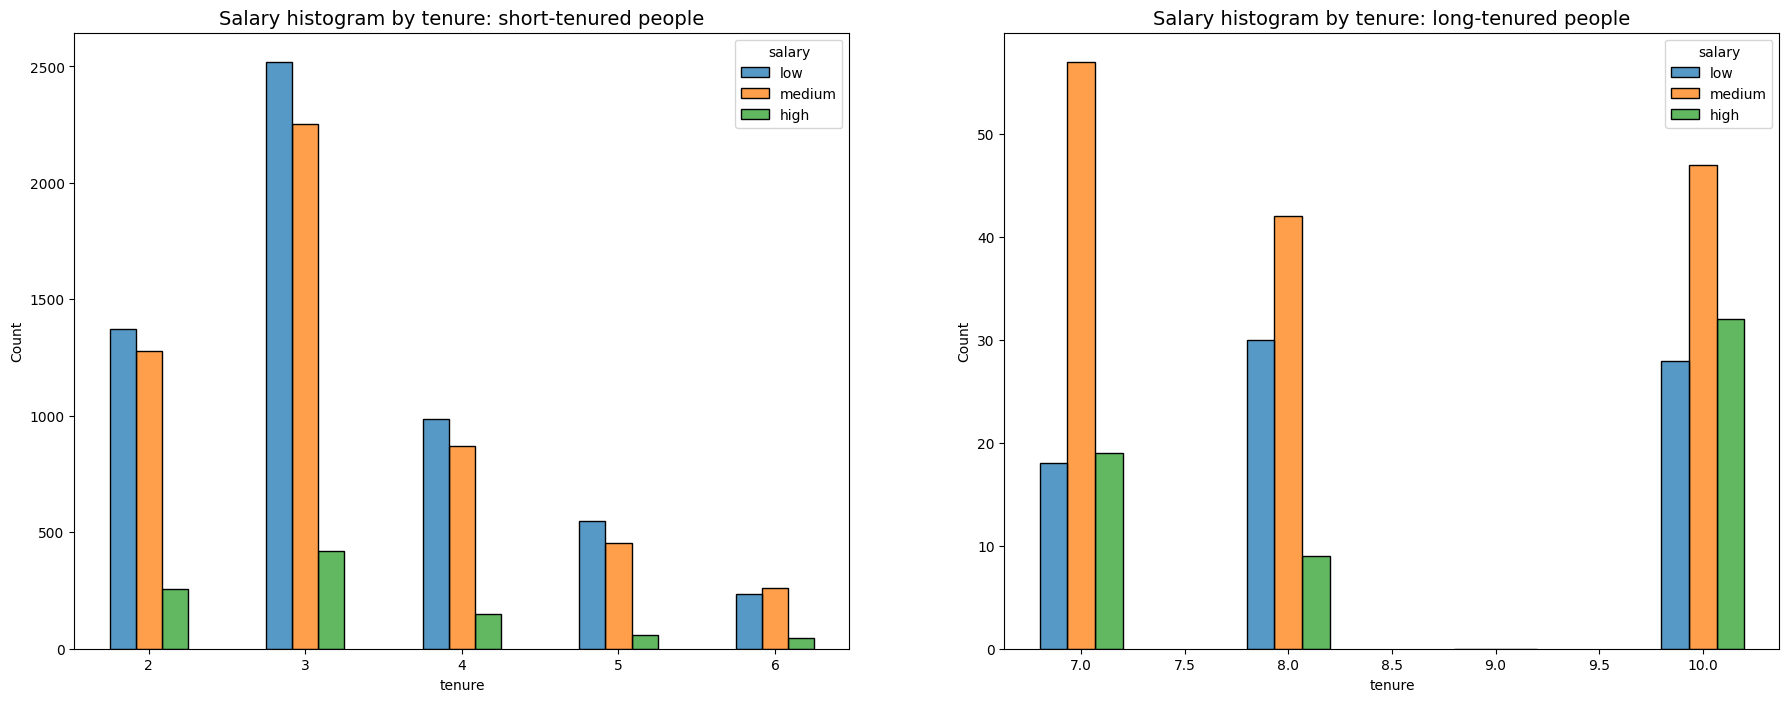

In [16]:
### Charting the distribution of `tenure`
fig, ax = plt.subplots(1, 2, figsize = (22,8))

tenure_short = df[df['tenure'] < 7]

tenure_long = df[df['tenure'] > 6]

sns.histplot(data=tenure_short, x='tenure', hue='salary', discrete=1, 
             hue_order=['low', 'medium', 'high'], multiple='dodge', shrink=.5, ax=ax[0])
ax[0].set_title('Salary histogram by tenure: short-tenured people', fontsize='14')

sns.histplot(data=tenure_long, x='tenure', hue='salary', discrete=1, 
             hue_order=['low', 'medium', 'high'], multiple='dodge', shrink=.4, ax=ax[1])
ax[1].set_title('Salary histogram by tenure: long-tenured people', fontsize='14');

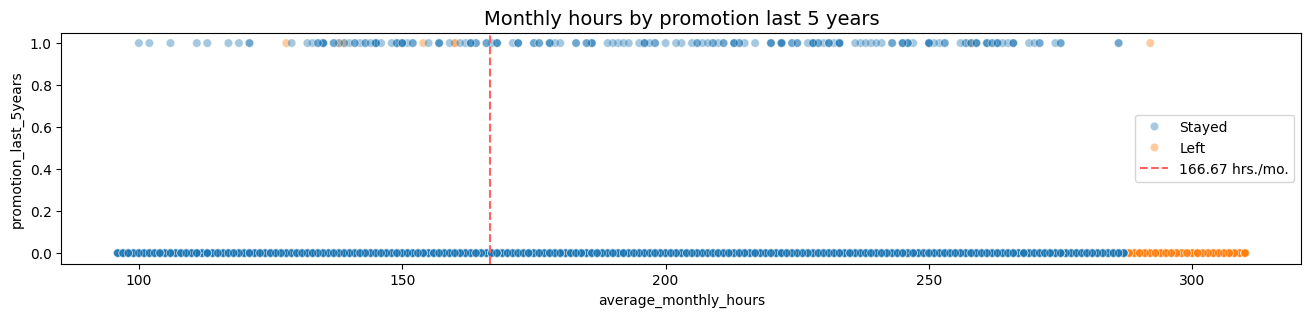

In [17]:
### Monthly hours by promotion last 5 years, comparing employees who stayed versus those who left (Fixed legend mapping)
plt.figure(figsize=(16, 3))
scatter = sns.scatterplot(data=df, x='average_monthly_hours', y='promotion_last_5years', hue='left', alpha=0.4)
line = plt.axvline(x=166.67, color='#ff6361', ls='--')

# Correctly assign legend labels using handles
handles, labels = scatter.get_legend_handles_labels()
handles.append(line)
plt.legend(handles=handles, labels=['Stayed', 'Left', '166.67 hrs./mo.'])
plt.title('Monthly hours by promotion last 5 years', fontsize='14')
plt.show()

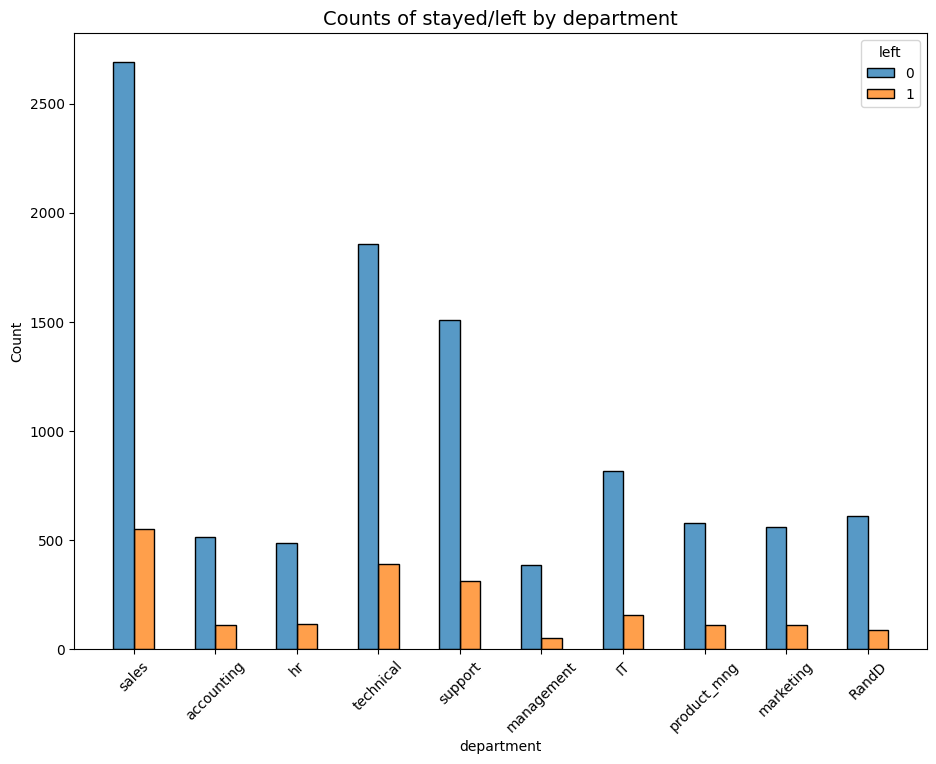

In [18]:
### Counts of stayed/left by department
plt.figure(figsize=(11,8))
sns.histplot(data=df, x='department', hue='left', discrete=1, 
             hue_order=[0, 1], multiple='dodge', shrink=.5)
plt.xticks(rotation=45)
plt.title('Counts of stayed/left by department', fontsize=14);


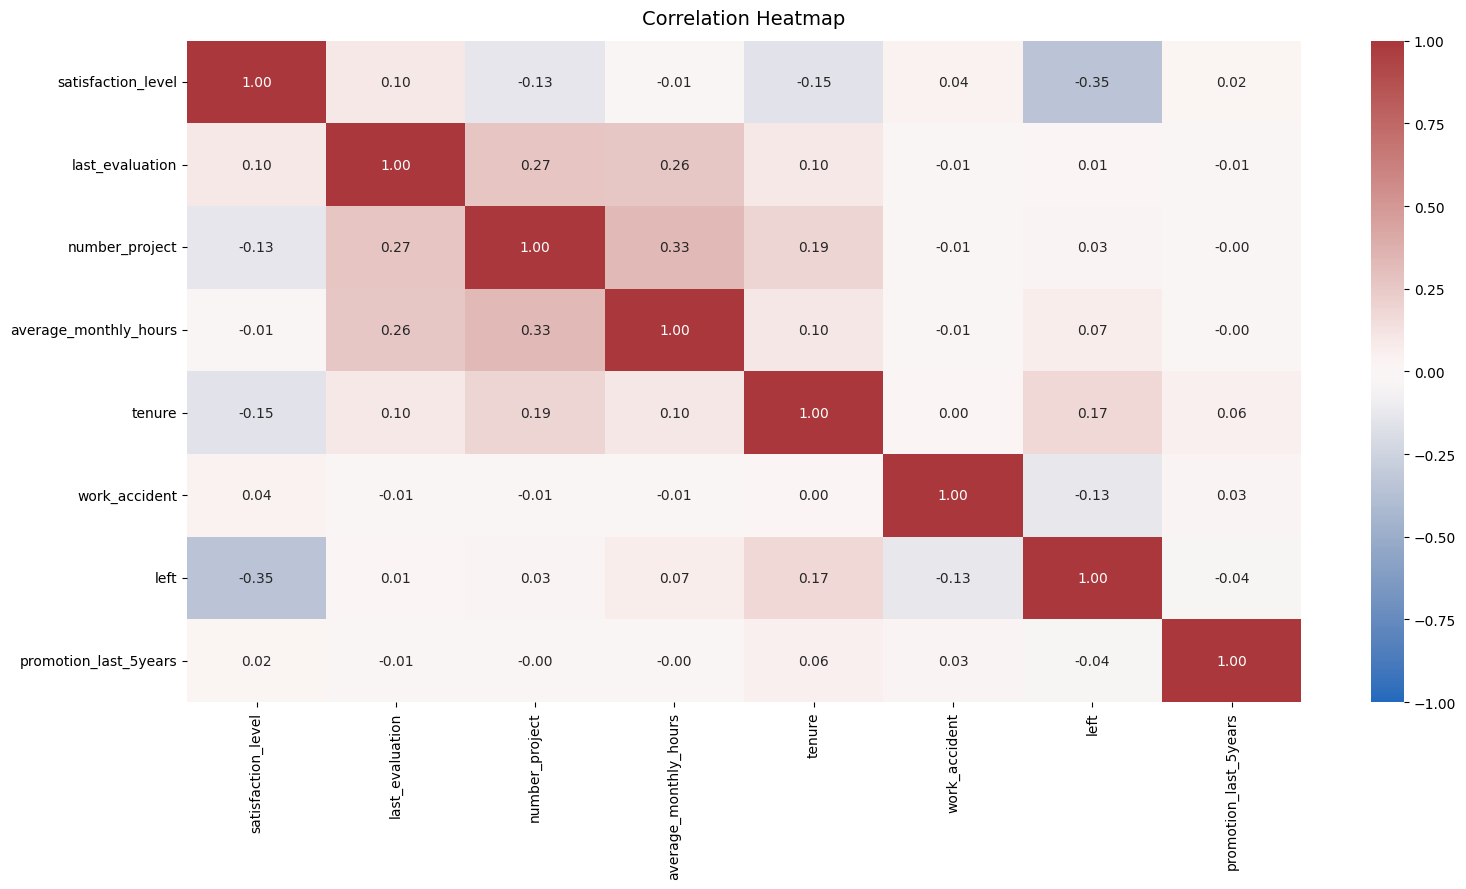

In [19]:
### Correlation heatmap for numeric features
plt.figure(figsize=(16, 9))

corr_matrix = df.select_dtypes(include='number').corr()

sns.heatmap(
    corr_matrix,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt='.2f',
    cmap='vlag'
)

plt.title('Correlation Heatmap', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

In [20]:
### Feature Engineering using modular src package
import sys
sys.path.append('../src')
from preprocessing import engineer_features

df_processed = engineer_features(df)
df_processed.to_csv('../data/processed/cleaned_HR_data.csv', index=False)

print("--- FACTORY CHECK: FEATURE ENGINEERING COMPLETO ---")
print(f"1. Cleaned Dataset: {df_processed.shape}")
print("2. Data Types:")
print(df_processed.dtypes.head())

--- FACTORY CHECK: FEATURE ENGINEERING COMPLETO ---
1. Cleaned Dataset: (11991, 18)
2. Data Types:
satisfaction_level       float64
last_evaluation          float64
number_project             int64
average_monthly_hours      int64
tenure                     int64
dtype: object


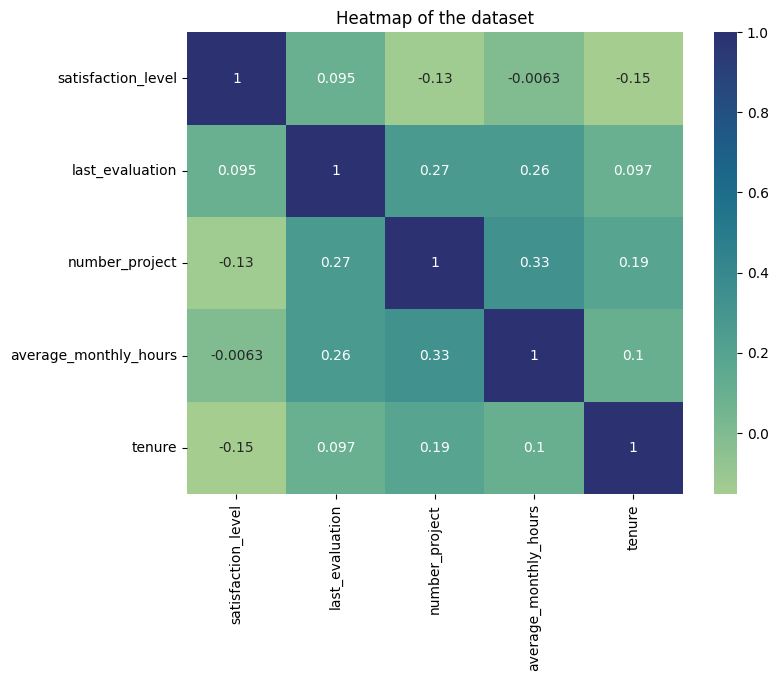

In [21]:
### Correlation heatmap for selected features
plt.figure(figsize=(8, 6))
sns.heatmap(df_processed[['satisfaction_level', 'last_evaluation', 'number_project', 'average_monthly_hours', 'tenure']]
            .corr(), annot=True, cmap="crest")
plt.title('Heatmap of the dataset')
plt.show()

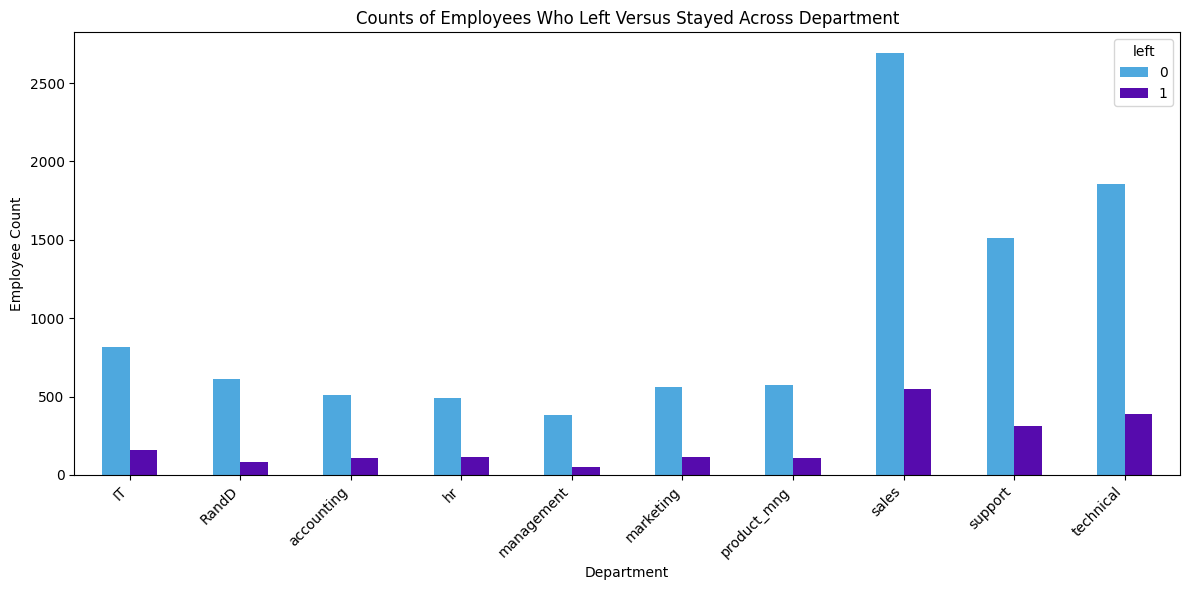

In [22]:
###Bar chart showing counts of employees who left versus stayed across department

tabla_departamentos = pd.crosstab(df['department'], df['left'])

tabla_departamentos.plot(kind='bar', color=['#4ea8de', '#560bad'], figsize=(12, 6))

plt.title('Counts of Employees Who Left Versus Stayed Across Department')
plt.ylabel('Employee Count')
plt.xlabel('Department')
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()

In [23]:
### Train Logistic Regression models using modular src package
import sys
sys.path.append('../src')
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from modeling import train_logistic_regression

# 1. Separate features (X) and target variable (y)
X = df_processed.drop(columns=['left'])
y = df_processed['left']

# 2. Stratified train/test split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 3. Train baseline and balanced Logistic Regression models
print("=== LOGISTIC REGRESSION (BASELINE) ===")
log_model, scaler, y_pred_log, y_prob_log = train_logistic_regression(X_train, X_test, y_train, y_test, balanced=False)
print(classification_report(y_test, y_pred_log))

print("\n=== LOGISTIC REGRESSION (BALANCED CLASS WEIGHTS) ===")
log_model_bal, scaler_bal, y_pred_log_bal, y_prob_log_bal = train_logistic_regression(X_train, X_test, y_train, y_test, balanced=True)
print(classification_report(y_test, y_pred_log_bal))

=== LOGISTIC REGRESSION (BASELINE) ===
              precision    recall  f1-score   support

           0       0.86      0.96      0.91      2001
           1       0.50      0.19      0.28       398

    accuracy                           0.83      2399
   macro avg       0.68      0.58      0.59      2399
weighted avg       0.80      0.83      0.80      2399


=== LOGISTIC REGRESSION (BALANCED CLASS WEIGHTS) ===
              precision    recall  f1-score   support

           0       0.96      0.77      0.85      2001
           1       0.42      0.84      0.56       398

    accuracy                           0.78      2399
   macro avg       0.69      0.81      0.71      2399
weighted avg       0.87      0.78      0.81      2399



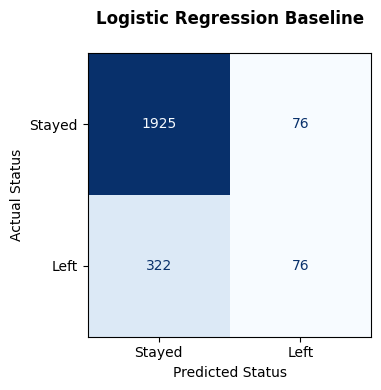

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Compute matrix
cm_log = confusion_matrix(y_test, y_pred_log)

# 2. Plot with minimalist styling
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=['Stayed', 'Left'])

# Plot using a clean, professional blue colormap without the colorbar clutter
disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)

# 3. Minimalist titles
ax.set_title('Logistic Regression Baseline\n', fontsize=12, weight='bold')
ax.set_xlabel('Predicted Status', fontsize=10)
ax.set_ylabel('Actual Status', fontsize=10)
ax.grid(False)

plt.tight_layout()
plt.show()

In [25]:
### Tune Decision Tree using modular src package
import sys
sys.path.append('../src')
from modeling import tune_decision_tree
from sklearn.metrics import classification_report

# Tune decision tree
print("=== DECISION TREE TUNING ===")
tree_grid = tune_decision_tree(X_train, y_train)
best_tree_model = tree_grid.best_estimator_
y_pred_tree = best_tree_model.predict(X_test)

print("Best Parameters:", tree_grid.best_params_)
print("\n=== DECISION TREE CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred_tree))

=== DECISION TREE TUNING ===


Best Parameters: {'max_depth': 8, 'min_samples_leaf': 2}

=== DECISION TREE CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2001
           1       0.97      0.93      0.95       398

    accuracy                           0.98      2399
   macro avg       0.98      0.96      0.97      2399
weighted avg       0.98      0.98      0.98      2399



In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

def make_results(model_name: str, model_object, metric: str):
    metric_dict = {
        'auc': 'mean_test_roc_auc',
        'precision': 'mean_test_precision',
        'recall': 'mean_test_recall',
        'f1': 'mean_test_f1',
        'accuracy': 'mean_test_accuracy'
    }
    cv_results = pd.DataFrame(model_object.cv_results_)
    best_estimator_results = cv_results.iloc[cv_results[metric_dict[metric]].idxmax(), :]
    
    table = pd.DataFrame({
        'model': [model_name],
        'precision': [best_estimator_results.mean_test_precision],
        'recall': [best_estimator_results.mean_test_recall],
        'F1': [best_estimator_results.mean_test_f1],
        'accuracy': [best_estimator_results.mean_test_accuracy],
        'auc': [best_estimator_results.mean_test_roc_auc]
    })
    return table

# 2. Run GridSearchCV supporting multiple metrics so the function gets the AUC score
param_grid_tree = {
    'max_depth': [4, 6, 8, 10],
    'min_samples_leaf': [2, 5, 10, 20]
}

# We pass a list of metrics to scoring, and set refit='f1' so it still optimizes for F1-score
tree_grid_multi = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42), 
    param_grid=param_grid_tree, 
    scoring=['f1', 'recall', 'precision', 'accuracy', 'roc_auc'], 
    refit='f1',
    cv=5, 
    n_jobs=-1
)

# 3. Fit the model
tree_grid_multi.fit(X_train, y_train)

# 4. Generate and display the clean results table
tree_results_table = make_results('Decision Tree (Tuned)', tree_grid_multi, 'f1')
tree_results_table

,model,precision,recall,F1,accuracy,auc
0,Decision Tree (Tuned),0.970376,0.919022,0.943937,0.98186,0.962285


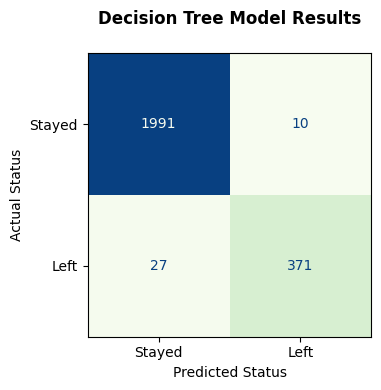

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Compute the Decision Tree confusion matrix
cm_tree = confusion_matrix(y_test, y_pred_tree)

# 2. Build the minimalist plot
fig, ax = plt.subplots(figsize=(5, 4))
disp_tree = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=['Stayed', 'Left'])

# Use a clean 'GnBu' (Green-Blue/Teal) colormap to differentiate this section visually
disp_tree.plot(ax=ax, cmap='GnBu', values_format='d', colorbar=False)

# 3. Minimalist titles
ax.set_title('Decision Tree Model Results\n', fontsize=12, weight='bold')
ax.set_xlabel('Predicted Status', fontsize=10)
ax.set_ylabel('Actual Status', fontsize=10)
ax.grid(False)

plt.tight_layout()
plt.show()

In [28]:
### Tune Random Forest (with proper feature bagging) using modular src package
import sys
sys.path.append('../src')
from modeling import tune_random_forest

print("=== RANDOM FOREST TUNING ===")
# Run GridSearch with correct max_features options
%time rf1 = tune_random_forest(X_train, y_train)
best_rf_model = rf1.best_estimator_
print("Best Parameters:", rf1.best_params_)

=== RANDOM FOREST TUNING ===


CPU times: user 5.92 s, sys: 423 ms, total: 6.34 s
Wall time: 1min 22s
Best Parameters: {'max_depth': None, 'max_features': 0.5, 'max_samples': 0.7, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}


In [29]:
import os
import pickle

# Create a local directory for models if it doesn't exist
os.makedirs('models', exist_ok=True)
local_path = 'models/hr_rf1.pickle'

# Save the trained model object securely
with open(local_path, 'wb') as to_write:
    pickle.dump(rf1, to_write)

print(f"Model successfully saved to local directory: {local_path}")

Model successfully saved to local directory: models/hr_rf1.pickle


In [30]:
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

def get_scores(model_name: str, model_object, X_test_data, y_test_data):
    preds = model_object.best_estimator_.predict(X_test_data)
    table = pd.DataFrame({
        'model': [model_name],
        'precision': [precision_score(y_test_data, preds)], 
        'recall': [recall_score(y_test_data, preds)],
        'f1': [f1_score(y_test_data, preds)],
        'accuracy': [accuracy_score(y_test_data, preds)],
        'AUC': [roc_auc_score(y_test_data, preds)]
    })
    return table

# Compute and present the final test row
rf1_test_scores = get_scores('Random Forest (Test Set)', rf1, X_test, y_test)
rf1_test_scores

,model,precision,recall,f1,accuracy,AUC
0,Random Forest (Test Set),0.989276,0.927136,0.957198,0.986244,0.962568


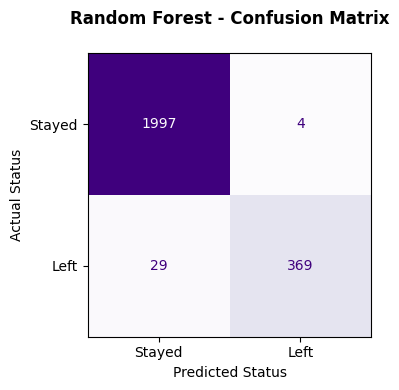

In [31]:
###Confusion matrix for the optimized Random Forest model
y_pred_rf = rf1.best_estimator_.predict(X_test)

cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(5, 4))
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Stayed', 'Left'])
disp_rf.plot(ax=ax, cmap='Purples', values_format='d', colorbar=False)

ax.set_title('Random Forest - Confusion Matrix\n', fontsize=12, weight='bold')
ax.set_xlabel('Predicted Status', fontsize=10)
ax.set_ylabel('Actual Status', fontsize=10)
ax.grid(False)

plt.tight_layout()
plt.show()

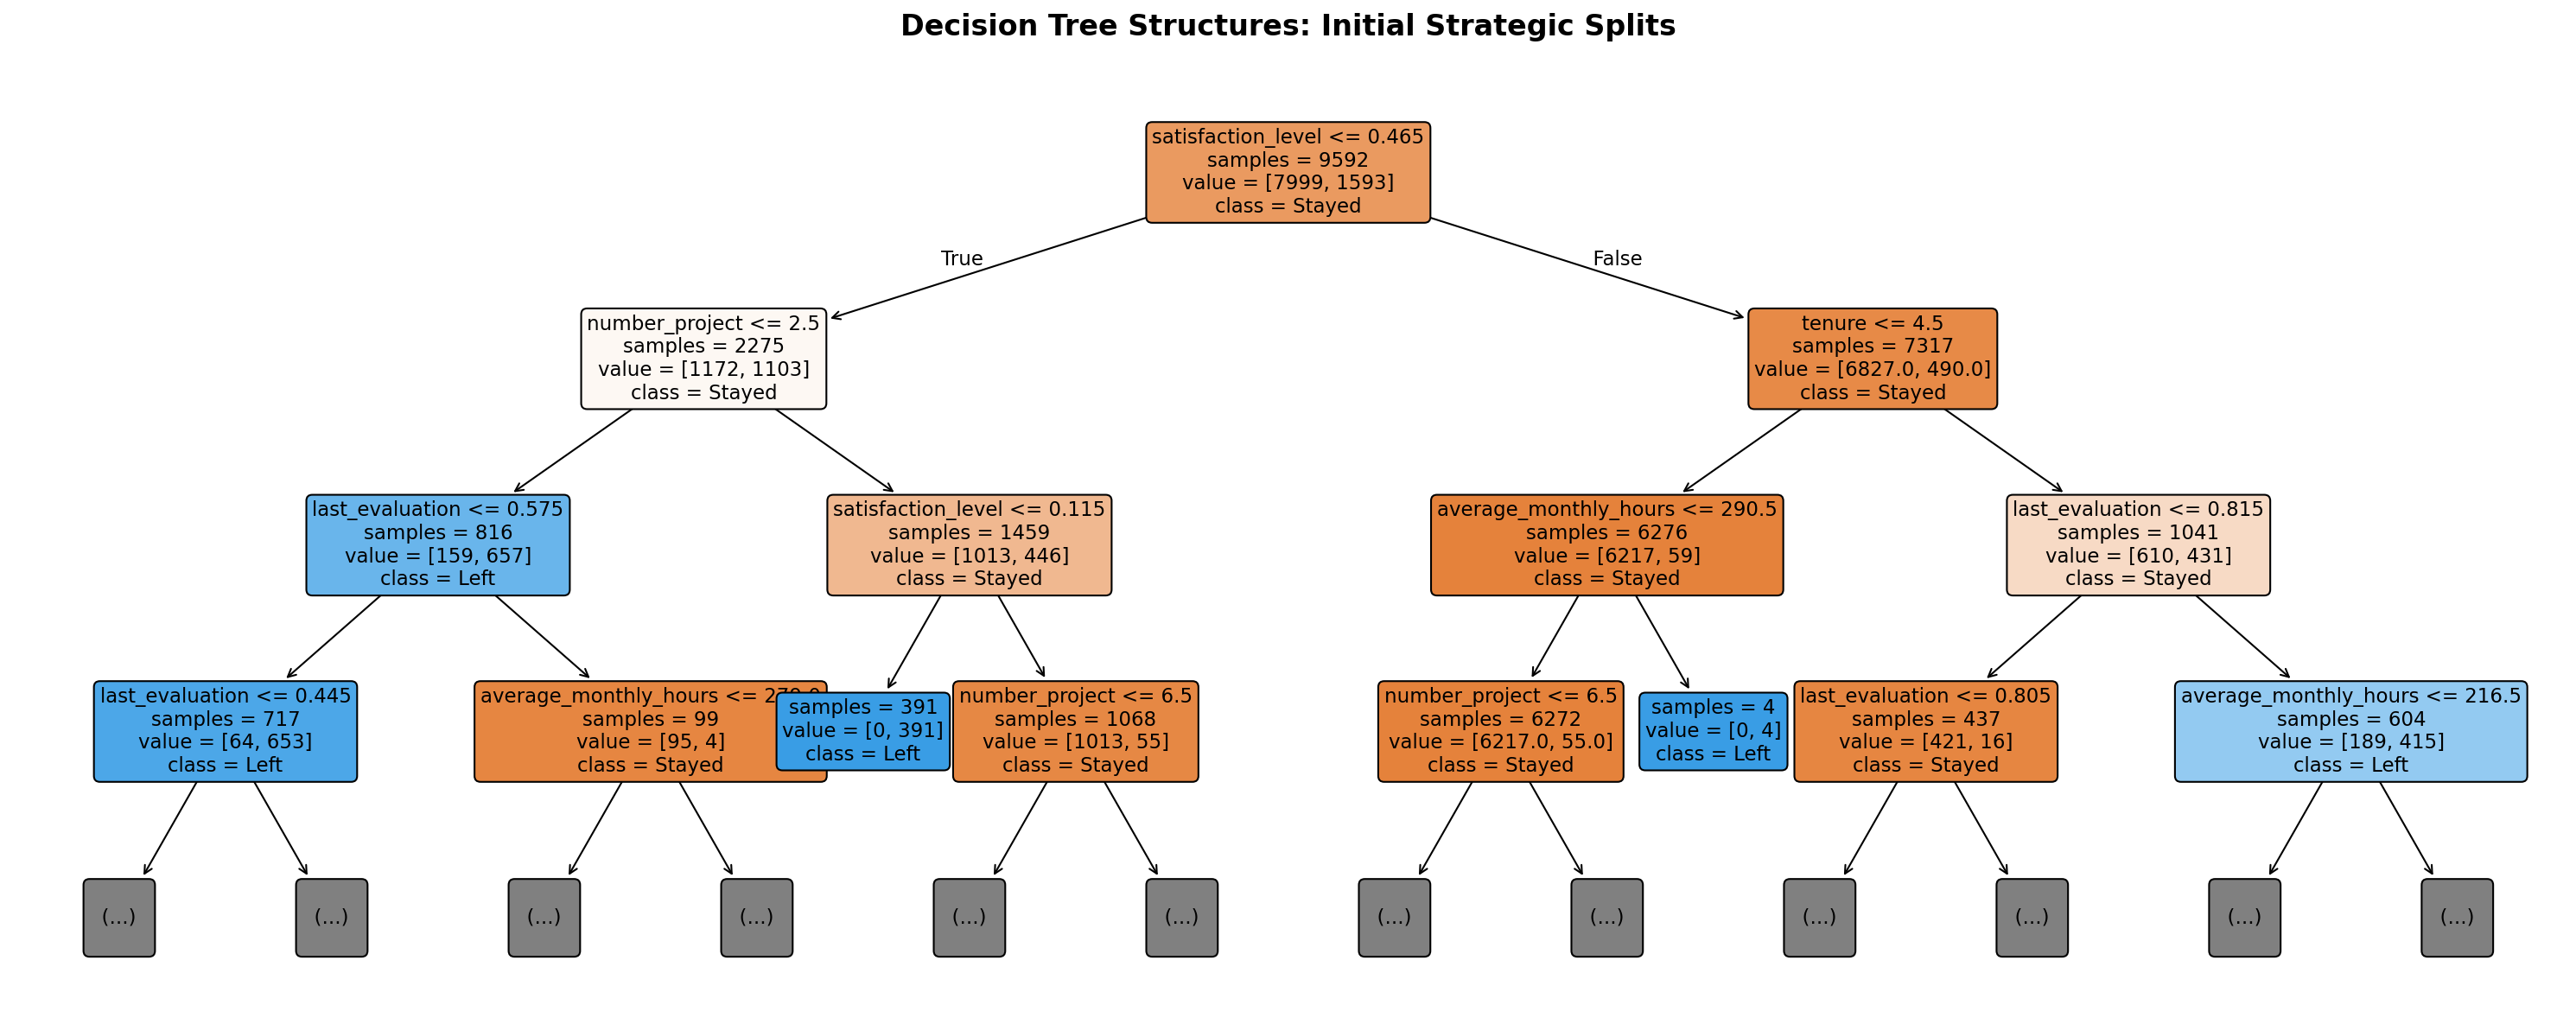

In [78]:
###plotting the structure of the optimized decision tree model
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 8), dpi=150)

plot_tree(
    tree_grid_multi.best_estimator_, 
    max_depth=3,                          
    feature_names=list(X_train.columns),  
    class_names=['Stayed', 'Left'],        
    filled=True,                          
    impurity=False,                       
    rounded=True,                         
    fontsize=11
)

plt.title('Decision Tree Structures: Initial Strategic Splits\n', fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

In [33]:
###Feature importance plot for the optimized decision tree model
tree2_importances = pd.DataFrame(
    tree_grid_multi.best_estimator_.feature_importances_, 
    columns=['gini_importance'], 
    index=X.columns
)

tree2_importances = tree2_importances.sort_values(by='gini_importance', ascending=False)
tree2_importances = tree2_importances[tree2_importances['gini_importance'] > 0]
tree2_importances

,gini_importance
satisfaction_level,0.487101
last_evaluation,0.170414
tenure,0.128326
number_project,0.127237
average_monthly_hours,0.084689
salary,0.001866
department_support,0.000118
department_accounting,0.000099
department_hr,0.000094
department_technical,0.000055


/tmp/ipykernel_48182/986692215.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


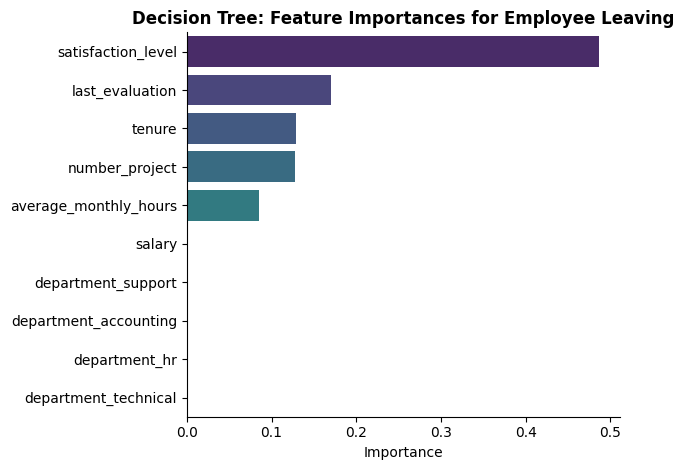

In [34]:
###Charting the feature importances for the optimized decision tree model
sns.barplot(
    data=tree2_importances, 
    x="gini_importance", 
    y=tree2_importances.index, 
    orient='h',
    palette="viridis"
)

plt.title("Decision Tree: Feature Importances for Employee Leaving", fontsize=12, weight='bold')
plt.xlabel("Importance")
plt.ylabel("")

sns.despine()

plt.tight_layout()
plt.show()

/tmp/ipykernel_48182/1461265340.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


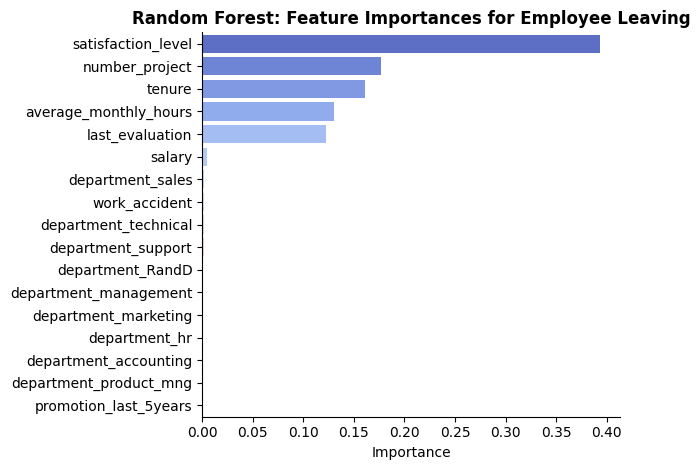

In [35]:
###Feature importance plot for the optimized random forest model
rf_importances = pd.DataFrame(
    rf1.best_estimator_.feature_importances_, 
    columns=['gini_importance'], 
    index=X_train.columns
)
rf_importances = rf_importances.sort_values(by='gini_importance', ascending=False)
rf_importances = rf_importances[rf_importances['gini_importance'] > 0]

sns.barplot(
    data=rf_importances, 
    x="gini_importance", 
    y=rf_importances.index, 
    orient='h',
    palette="coolwarm"
)

plt.title("Random Forest: Feature Importances for Employee Leaving", fontsize=12, weight='bold')
plt.xlabel("Importance")
plt.ylabel("")

sns.despine()
plt.tight_layout()
plt.show()